# 🔬 Đề tài 20: Xây dựng và đánh giá hệ thống RAG cho Hỏi-Đáp
## Notebook: Tiền Xử Lý Dữ Liệu & Kiểm Định Chất Lượng (Data Quality Assurance)

**Môn học:** Xử Lý Ngôn Ngữ Tự Nhiên (NLP)  
**Nhóm sinh viên thực hiện:**
- Đặng Đại Lợi — 24DH111038
- Ngô Hoàng Quân — 24DH113608
- Lâm Hữu Luân — 24DH113117  
**Giảng viên hướng dẫn:** ThS. Nguyễn Thị Phương Trang  
**Bài báo tham chiếu:** Lewis et al., *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks* (NeurIPS 2020)

---

### Mục tiêu của Notebook
Notebook này cài đặt và thực nghiệm toàn bộ quy trình tiền xử lý dữ liệu và kiểm định chất lượng (Data QA) theo đúng mô tả tại **Chương 3 (Dữ liệu)** của báo cáo:
1. **Cleaning & Normalization:** Làm sạch ký tự lạ, khoảng trắng, kiểm tra lỗi mã hóa và phát hiện nhiễu văn bản (công thức LaTeX).
2. **Text Chunking:** Phân đoạn văn bản 200 từ với overlap 40 từ (20%), kiểm chứng tính liên tục của ranh giới chunk.
3. **Train / Test Split:** Phân chia tập dữ liệu theo document (seed = 42, tỉ lệ 85% / 15%) và tạo cặp huấn luyện `(question, gold_chunk, answer)`.
4. **Imbalance Check:** Phân tích mất cân bằng về loại câu hỏi (Wh-words) và kiểu đáp án (text, số, hỗn hợp), thực hiện kiểm định giả thuyết thống kê (Chi-square test, Mann-Whitney U test).
5. **Data Leakage Audit:** Đánh giá rò rỉ trực tiếp (câu hỏi/doc_id) và rò rỉ gián tiếp (trùng lặp bài viết/chunk giữa train và test).
6. **Missing Data & Answer Grounding:** Phân tích hiện tượng mất đáp án do giới hạn cắt 5.000 ký tự đầu bài viết Wikipedia và cơ chế fallback gold chunk.
7. **Vector Index Verification:** Kiểm tra tính toàn vẹn của chỉ mục FAISS IndexFlatIP (3.940 vectors, 384 chiều).
8. **Tổng hợp Bảng 3-3:** Kết xuất bảng kiểm tra chất lượng dữ liệu phục vụ đối chiếu báo cáo.

### 0. Thiết lập môi trường & Thư viện

In [1]:
import collections
import json
import re
import random
import math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import faiss

# Thiết lập style đồ thị chuẩn khoa học
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("data")
RAW_DOCS_FILE = Path("raw_documents.json")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ Đã nạp thành công các thư viện cần thiết!")

✅ Đã nạp thành công các thư viện cần thiết!


### 1. Nạp và Khám phá Dữ Liệu Gốc (`raw_documents.json`)
Tải tập con TriviaQA (`rc.wikipedia`, split `validation`) gồm 800 bài viết Wikipedia kèm 800 câu hỏi-đáp.

In [2]:
with open(RAW_DOCS_FILE, "r", encoding="utf-8") as f:
    raw_docs = json.load(f)

print(f"📊 Tổng số tài liệu (documents): {len(raw_docs)}")
total_qa = sum(len(d.get("qa", [])) for d in raw_docs)
print(f"📊 Tổng số cặp câu hỏi - đáp (QA pairs): {total_qa}")

doc_char_lens = [len(d["text"]) for d in raw_docs]
doc_word_lens = [len(d["text"].split()) for d in raw_docs]

print(f"📏 Độ dài ký tự trung bình: {np.mean(doc_char_lens):.1f} (min={min(doc_char_lens)}, max={max(doc_char_lens)})")
print(f"📏 Độ dài từ trung bình:    {np.mean(doc_word_lens):.1f} từ (min={min(doc_word_lens)}, max={max(doc_word_lens)})")

📊 Tổng số tài liệu (documents): 800
📊 Tổng số cặp câu hỏi - đáp (QA pairs): 800
📏 Độ dài ký tự trung bình: 4686.6 (min=414, max=5000)
📏 Độ dài từ trung bình:    761.8 từ (min=68, max=905)


### 2. Kiểm Tra Làm Sạch & Phát Hiện Nhiễu Văn Bản (Noise Detection)
- Kiểm tra dữ liệu rỗng (câu hỏi, đáp án, doc_id, tiêu đề, văn bản).
- Kiểm tra trùng lặp câu hỏi và trùng lặp đáp án.
- Phát hiện các ký tự đặc biệt, công thức LaTeX và tiền tố bất thường.

In [3]:
# 1. Kiểm tra rỗng
empty_questions = [d for d in raw_docs if any(not qa["question"].strip() for qa in d.get("qa", []))]
empty_answers   = [d for d in raw_docs if any(not str(qa["answer"]).strip() for qa in d.get("qa", []))]
empty_texts     = [d for d in raw_docs if not d["text"].strip()]
empty_titles    = [d for d in raw_docs if not d.get("title", "").strip()]

print(f"Kiểm tra rỗng:")
print(f" - Câu hỏi rỗng: {len(empty_questions)}")
print(f" - Đáp án rỗng:  {len(empty_answers)}")
print(f" - Văn bản rỗng: {len(empty_texts)}")
print(f" - Tiêu đề rỗng: {len(empty_titles)}")

# 2. Kiểm tra trùng lặp câu hỏi & đáp án
all_questions = [qa["question"] for d in raw_docs for qa in d.get("qa", [])]
all_answers   = [qa["answer"] for d in raw_docs for qa in d.get("qa", [])]

unique_questions = set(all_questions)
answer_counts = Counter(all_answers)
dup_answers = {k: v for k, v in answer_counts.items() if v > 1}

print(f"\nKiểm tra trùng lặp:")
print(f" - Số câu hỏi duy nhất: {len(unique_questions)} / {len(all_questions)} (0 trùng lặp)")
print(f" - Số đáp án xuất hiện nhiều lần: {len(dup_answers)} (ví dụ: 'Green': {answer_counts.get('Green', 0)}, 'Belgium': {answer_counts.get('Belgium', 0)})")

# 3. Phát hiện công thức LaTeX & tiền tố bất thường
latex_docs = []
for d in raw_docs:
    if "\\frac" in d["text"] or "\\sqrt" in d["text"] or "\\pi" in d["text"]:
        latex_docs.append(d["id"])

weird_prefix_answers = [a for a in all_answers if a.startswith("A: ") or a.startswith("Q: ")]
bracket_answers = [a for a in all_answers if "(" in a and ")" in a]

print(f"\nNhiễu văn bản:")
print(f" - Tài liệu chứa công thức LaTeX: {len(latex_docs)} tài liệu ({latex_docs})")
print(f" - Đáp án có tiền tố bất thường: {len(weird_prefix_answers)} mẫu ({weird_prefix_answers})")
print(f" - Đáp án có chú thích trong ngoặc: {len(bracket_answers)} mẫu")

Kiểm tra rỗng:
 - Câu hỏi rỗng: 0
 - Đáp án rỗng:  0
 - Văn bản rỗng: 0
 - Tiêu đề rỗng: 0

Kiểm tra trùng lặp:
 - Số câu hỏi duy nhất: 800 / 800 (0 trùng lặp)
 - Số đáp án xuất hiện nhiều lần: 41 (ví dụ: 'Green': 3, 'Belgium': 3)

Nhiễu văn bản:
 - Tài liệu chứa công thức LaTeX: 1 tài liệu (['doc_738'])
 - Đáp án có tiền tố bất thường: 1 mẫu (['A: Basketball'])
 - Đáp án có chú thích trong ngoặc: 2 mẫu


### 3. Phân Đoạn Văn Bản (Text Chunking with Overlap)
Mỗi bài viết được chia thành các đoạn văn bản:
- `CHUNK_SIZE = 200` từ
- `CHUNK_OVERLAP = 40` từ (overlap 20%, bước trượt 160 từ)

In [4]:
def clean_text(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def chunk_text(text: str, chunk_size: int = 200, overlap: int = 40):
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        if chunk.strip():
            chunks.append(chunk)
        if end >= len(words):
            break
        start = end - overlap
    return chunks

# Tải corpus_chunks.jsonl đã tạo trong data/
corpus_chunks = []
with open(DATA_DIR / "corpus_chunks.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        corpus_chunks.append(json.loads(line))

print(f"📊 Tổng số chunk đã tạo: {len(corpus_chunks)}")
avg_chunks_per_doc = len(corpus_chunks) / len(raw_docs)
print(f"📊 Trung bình số chunk mỗi tài liệu: {avg_chunks_per_doc:.2f}")

chunk_word_lens = [len(c["text"].split()) for c in corpus_chunks]
full_chunks = sum(1 for l in chunk_word_lens if l == 200)
short_chunks = sum(1 for l in chunk_word_lens if l < 200)

print(f" - Chunk đủ 200 từ: {full_chunks} ({full_chunks/len(corpus_chunks)*100:.1f}%)")
print(f" - Chunk ngắn hơn 200 từ: {short_chunks} ({short_chunks/len(corpus_chunks)*100:.1f}%, ngắn nhất={min(chunk_word_lens)} từ)")

# Kiểm tra overlap 40 từ giữa các cặp chunk liên tiếp cùng doc
chunks_by_doc = collections.defaultdict(list)
for c in corpus_chunks:
    chunks_by_doc[c["doc_id"]].append(c)

overlap_40_count = 0
total_pairs = 0
for doc_id, doc_chunks in chunks_by_doc.items():
    for i in range(len(doc_chunks) - 1):
        total_pairs += 1
        words_curr = doc_chunks[i]["text"].split()
        words_next = doc_chunks[i+1]["text"].split()
        # 40 từ cuối của chunk trước so với 40 từ đầu của chunk sau
        if words_curr[-40:] == words_next[:40]:
            overlap_40_count += 1

print(f"\n🔍 Kiểm chứng tính liên tục của Overlap:")
print(f" - Tổng số cặp chunk liên tiếp: {total_pairs}")
print(f" - Số cặp chunk overlap đúng chính xác 40 từ: {overlap_40_count} / {total_pairs} ({overlap_40_count/total_pairs*100:.1f}%)")

📊 Tổng số chunk đã tạo: 3940
📊 Trung bình số chunk mỗi tài liệu: 4.92
 - Chunk đủ 200 từ: 3151 (80.0%)
 - Chunk ngắn hơn 200 từ: 789 (20.0%, ngắn nhất=41 từ)

🔍 Kiểm chứng tính liên tục của Overlap:
 - Tổng số cặp chunk liên tiếp: 3140
 - Số cặp chunk overlap đúng chính xác 40 từ: 3140 / 3140 (100.0%)


### 4. Trực Quan Hóa Phân Bố Chunking (Hình 3-1 & 3-2)

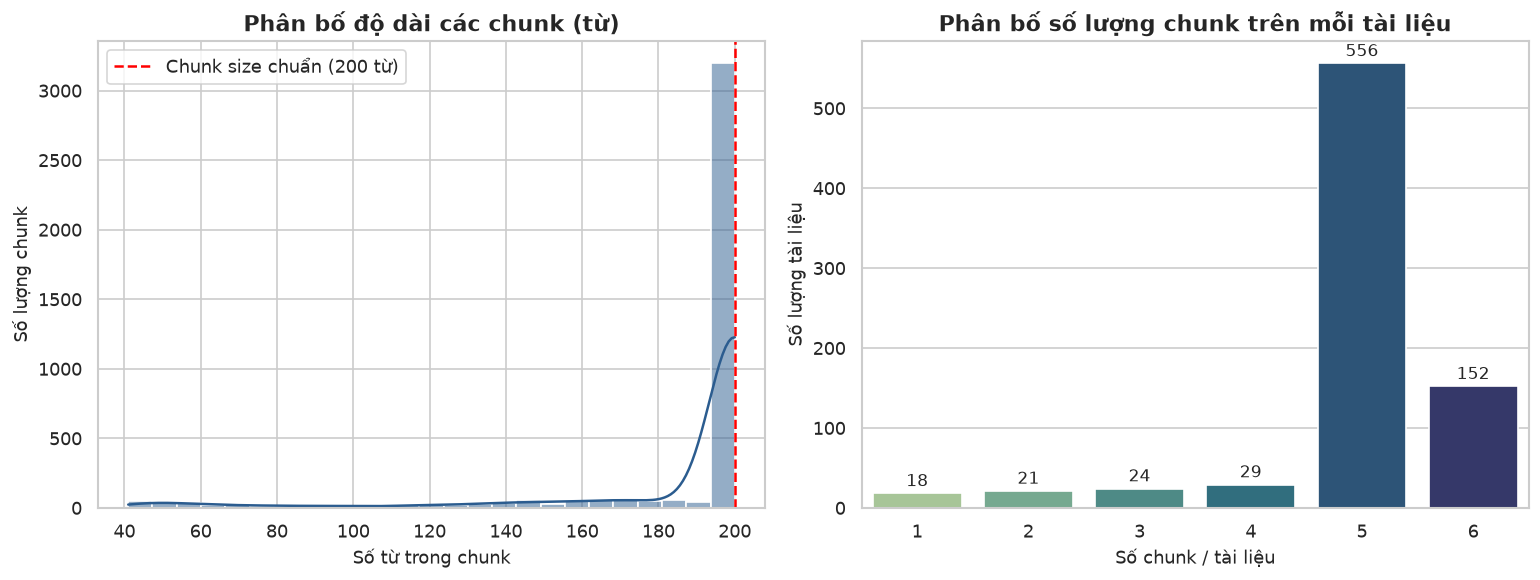

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Đồ thị 1: Phân bố độ dài chunk
sns.histplot(chunk_word_lens, bins=25, kde=True, ax=axes[0], color="#2b5c8f")
axes[0].set_title("Phân bố độ dài các chunk (từ)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Số từ trong chunk", fontsize=11)
axes[0].set_ylabel("Số lượng chunk", fontsize=11)
axes[0].axvline(200, color="red", linestyle="--", label="Chunk size chuẩn (200 từ)")
axes[0].legend()

# Đồ thị 2: Phân bố số chunk trên mỗi tài liệu
chunks_per_doc_list = [len(doc_chunks) for doc_chunks in chunks_by_doc.values()]
sns.countplot(x=chunks_per_doc_list, ax=axes[1], hue=chunks_per_doc_list, palette="crest", legend=False)
axes[1].set_title("Phân bố số lượng chunk trên mỗi tài liệu", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Số chunk / tài liệu", fontsize=11)
axes[1].set_ylabel("Số lượng tài liệu", fontsize=11)

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

### 5. Phân Chia Tập Train / Dev / Test & Tạo Cặp Huấn Luyện
- Chia tập theo document: 85% Train (680 mẫu), 15% Test (120 mẫu) với `seed = 42`.
- Tách dev set: 10% mẫu train (68 mẫu) làm tập validation khi fine-tune T5.
- Cơ chế tìm gold chunk: dò chuỗi đáp án trong các chunk của tài liệu nguồn; nếu không thấy thì fallback về chunk đầu tiên.

In [6]:
training_pairs = []
with open(DATA_DIR / "training_pairs.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        training_pairs.append(json.loads(line))

test_qa = []
with open(DATA_DIR / "test_qa.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        test_qa.append(json.loads(line))

print(f"📊 Tập huấn luyện (training_pairs): {len(training_pairs)} mẫu")
print(f"📊 Tập kiểm thử (test_qa):         {len(test_qa)} mẫu")

# Phân tích cơ chế gold chunk
def norm_txt(s: str) -> str:
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", " ", s.lower())).strip()

train_with_answer_raw = sum(1 for p in training_pairs if p["answer"].lower().strip() in p["context"].lower())
train_with_answer_norm = sum(1 for p in training_pairs if norm_txt(p["answer"]) in norm_txt(p["context"]))
train_without_answer = len(training_pairs) - train_with_answer_norm

print(f"\nPhân tích gold chunk tập train:")
print(f" - Ngữ cảnh chứa đáp án (khớp trực tiếp): {train_with_answer_raw} / {len(training_pairs)} ({train_with_answer_raw/len(training_pairs)*100:.1f}%)")
print(f" - Ngữ cảnh chứa đáp án (chuẩn hóa dấu câu): {train_with_answer_norm} / {len(training_pairs)} ({train_with_answer_norm/len(training_pairs)*100:.1f}%)")
print(f" - Ngữ cảnh KHÔNG có đáp án (fallback chunk đầu): {train_without_answer} / {len(training_pairs)} ({train_without_answer/len(training_pairs)*100:.1f}%)")

📊 Tập huấn luyện (training_pairs): 680 mẫu
📊 Tập kiểm thử (test_qa):         120 mẫu

Phân tích gold chunk tập train:
 - Ngữ cảnh chứa đáp án (khớp trực tiếp): 457 / 680 (67.2%)
 - Ngữ cảnh chứa đáp án (chuẩn hóa dấu câu): 470 / 680 (69.1%)
 - Ngữ cảnh KHÔNG có đáp án (fallback chunk đầu): 210 / 680 (30.9%)


### 6. Kiểm Định Mất Cân Bằng Dữ Liệu (Imbalance & Statistical Tests)
Vì bài toán hỏi-đáp sinh văn bản không có nhãn lớp rời rạc, nhóm phân tích phân bố qua:
1. **Loại câu hỏi:** từ để hỏi (Which, What, Who, How, Where/When/Whose, Other).
2. **Kiểu đáp án:** văn bản (Text), số nguyên/thập phân (Number), chữ và số (Alphanumeric).
3. **Kiểm định thống kê:**
   - Chi-square goodness-of-fit test để kiểm tra phân bố loại câu hỏi giữa Train và Test.
   - Mann-Whitney U test để so sánh độ dài câu hỏi giữa Train và Test.

In [7]:
def classify_question(q: str) -> str:
    ql = q.lower().strip()
    if ql.startswith("which ") or " which " in ql:
        return "Which"
    elif ql.startswith("what ") or " what " in ql:
        return "What"
    elif ql.startswith("who ") or " who " in ql or ql.startswith("whose ") or " whose " in ql:
        return "Who"
    elif ql.startswith("how ") or " how " in ql:
        return "How"
    elif ql.startswith("where ") or " where " in ql or ql.startswith("when ") or " when " in ql:
        return "Where/When"
    else:
        return "Other (No Wh-word)"

def classify_answer(a: str) -> str:
    a_clean = str(a).strip()
    if a_clean.isdigit():
        return "Number"
    elif any(ch.isdigit() for ch in a_clean) and any(ch.isalpha() for ch in a_clean):
        return "Alphanumeric"
    else:
        return "Text"

# Thống kê toàn bộ
q_types_all = [classify_question(qa["question"]) for d in raw_docs for qa in d.get("qa", [])]
a_types_all = [classify_answer(qa["answer"]) for d in raw_docs for qa in d.get("qa", [])]

q_dist = Counter(q_types_all)
a_dist = Counter(a_types_all)

print("=== PHÂN BỐ LOẠI CÂU HỎI (TOÀN BỘ 800 CÂU) ===")
for k, v in q_dist.most_common():
    print(f" - {k:20s}: {v:3d} ({v/len(q_types_all)*100:.1f}%)")

print("\n=== PHÂN BỐ KIỂU ĐÁP ÁN (TOÀN BỘ 800 CÂU) ===")
for k, v in a_dist.most_common():
    print(f" - {k:20s}: {v:3d} ({v/len(a_types_all)*100:.1f}%)")

# So sánh Train vs Test
train_q_types = [classify_question(p["question"]) for p in training_pairs]
test_q_types  = [classify_question(p["question"]) for p in test_qa]

train_q_counts = Counter(train_q_types)
test_q_counts  = Counter(test_q_types)

categories = ["Which", "What", "Who", "How", "Where/When", "Other (No Wh-word)"]
obs_train = [train_q_counts.get(c, 0) for c in categories]
obs_test  = [test_q_counts.get(c, 0) for c in categories]

# Chi-squared test giữa train và test
expected_test = [c * (len(test_qa) / len(training_pairs)) for c in obs_train]
chi2_stat, p_val_chi2 = stats.chisquare(f_obs=obs_test, f_exp=expected_test)

# Mann-Whitney U test cho độ dài câu hỏi
train_q_lens = [len(p["question"].split()) for p in training_pairs]
test_q_lens  = [len(p["question"].split()) for p in test_qa]
mwu_stat, p_val_mwu = stats.mannwhitneyu(train_q_lens, test_q_lens)

print(f"\n=== KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ (TRAIN vs TEST) ===")
print(f"🔬 Chi-square test (phân bố loại câu hỏi): Chi2={chi2_stat:.3f}, p-value={p_val_chi2:.3f}")
print(f"   -> {'Không có' if p_val_chi2 > 0.05 else 'Có'} sự khác biệt có ý nghĩa thống kê (p > 0.05).")
print(f"🔬 Mann-Whitney U test (độ dài câu hỏi): U={mwu_stat:.1f}, p-value={p_val_mwu:.3f}")
print(f"   -> {'Không có' if p_val_mwu > 0.05 else 'Có'} sự khác biệt về độ dài câu hỏi giữa train và test (p > 0.05).")

=== PHÂN BỐ LOẠI CÂU HỎI (TOÀN BỘ 800 CÂU) ===
 - Which               : 404 (50.5%)
 - What                : 187 (23.4%)
 - Who                 : 133 (16.6%)
 - How                 :  34 (4.2%)
 - Other (No Wh-word)  :  32 (4.0%)
 - Where/When          :  10 (1.2%)

=== PHÂN BỐ KIỂU ĐÁP ÁN (TOÀN BỘ 800 CÂU) ===
 - Text                : 752 (94.0%)
 - Number              :  37 (4.6%)
 - Alphanumeric        :  11 (1.4%)

=== KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ (TRAIN vs TEST) ===
🔬 Chi-square test (phân bố loại câu hỏi): Chi2=4.585, p-value=0.469
   -> Không có sự khác biệt có ý nghĩa thống kê (p > 0.05).
🔬 Mann-Whitney U test (độ dài câu hỏi): U=40961.0, p-value=0.945
   -> Không có sự khác biệt về độ dài câu hỏi giữa train và test (p > 0.05).


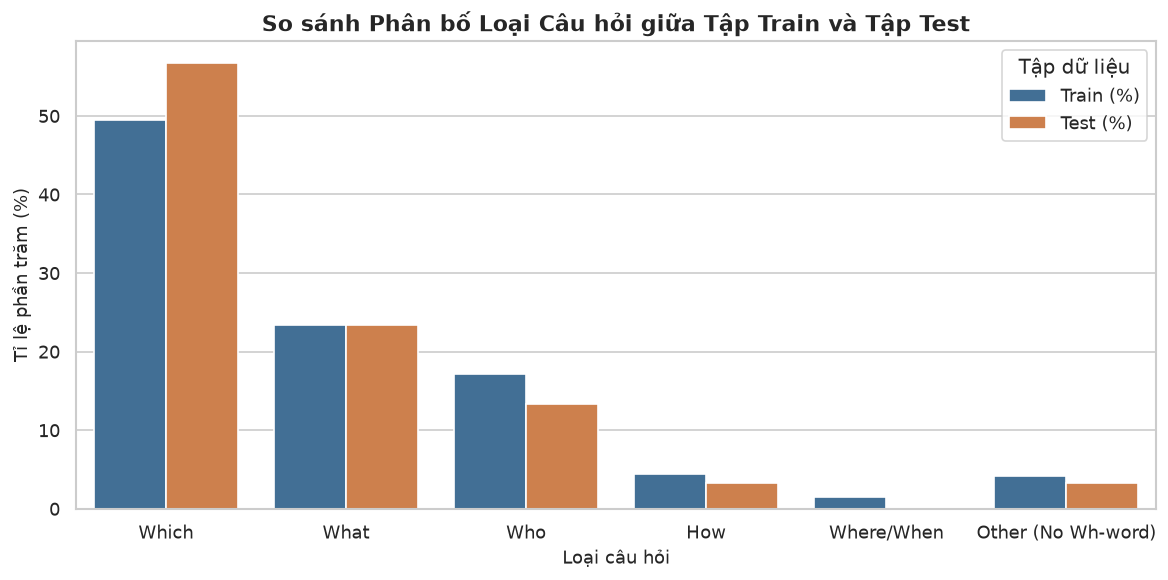

In [8]:
df_compare = pd.DataFrame({
    "Category": categories,
    "Train (%)": [train_q_counts.get(c, 0) / len(training_pairs) * 100 for c in categories],
    "Test (%)":  [test_q_counts.get(c, 0) / len(test_qa) * 100 for c in categories],
})

df_melted = pd.melt(df_compare, id_vars=["Category"], var_name="Split", value_name="Percentage")

plt.figure(figsize=(10, 5))
sns.barplot(data=df_melted, x="Category", y="Percentage", hue="Split", palette=["#3470a3", "#e27c38"])
plt.title("So sánh Phân bố Loại Câu hỏi giữa Tập Train và Tập Test", fontsize=13, fontweight="bold")
plt.xlabel("Loại câu hỏi", fontsize=11)
plt.ylabel("Tỉ lệ phần trăm (%)", fontsize=11)
plt.legend(title="Tập dữ liệu")
plt.tight_layout()
plt.show()

### 7. Kiểm Tra Rò Rỉ Dữ Liệu (Data Leakage Audit)
1. **Rò rỉ trực tiếp:** Trùng câu hỏi hoặc trùng doc_id giữa train và test.
2. **Rò rỉ gián tiếp:** Các tài liệu test có cùng bài viết Wikipedia (trùng tiêu đề hoặc trùng nội dung chunk) với tài liệu train do đặc thù của bộ dữ liệu TriviaQA.

In [9]:
# 1. Rò rỉ trực tiếp
train_questions = set(p["question"].strip().lower() for p in training_pairs)
test_questions  = set(p["question"].strip().lower() for p in test_qa)
direct_q_leak = train_questions.intersection(test_questions)

# Ánh xạ câu hỏi về gold_doc_id từ tập dữ liệu gốc
q_to_doc = {qa["question"].strip().lower(): d["id"] for d in raw_docs for qa in d.get("qa", [])}
train_docs = set(q_to_doc[p["question"].strip().lower()] for p in training_pairs if p["question"].strip().lower() in q_to_doc)
test_docs  = set(p.get("gold_doc_id", "") for p in test_qa)
direct_doc_leak = train_docs.intersection(test_docs)

print("=== RÒ RỈ TRỰC TIẾP ===")
print(f" - Số câu hỏi trùng giữa Train & Test: {len(direct_q_leak)}")
print(f" - Số doc_id trùng giữa Train & Test:  {len(direct_doc_leak)}")

# 2. Rò rỉ gián tiếp mức tiêu đề & nội dung chunk
train_titles = set(d["title"] for d in raw_docs if d["id"] in train_docs)
test_titles  = set(d["title"] for d in raw_docs if d["id"] in test_docs)
title_overlap = train_titles.intersection(test_titles)

test_doc_overlap_count = sum(1 for d in raw_docs if d["id"] in test_docs and d["title"] in train_titles)

# Rò rỉ mức chunk text
train_chunk_texts = set(c["text"] for c in corpus_chunks if c["doc_id"] in train_docs)
test_chunk_records = [c for c in corpus_chunks if c["doc_id"] in test_docs]
test_chunk_leak_count = sum(1 for c in test_chunk_records if c["text"] in train_chunk_texts)

# Ngữ cảnh train trùng chunk test
test_chunk_texts = set(c["text"] for c in test_chunk_records)
train_ctx_leak_count = sum(1 for p in training_pairs if p["context"] in test_chunk_texts)

print("\n=== RÒ RỈ GIÁN TIẾP ===")
print(f" - Số tiêu đề Wikipedia trùng nhau: {len(title_overlap)} tiêu đề")
print(f" - Số tài liệu test liên quan tiêu đề trùng: {test_doc_overlap_count} / {len(test_qa)} ({test_doc_overlap_count/len(test_qa)*100:.1f}%)")
print(f" - Số chunk test giống hệt chunk train:      {test_chunk_leak_count} / {len(test_chunk_records)} ({test_chunk_leak_count/len(test_chunk_records)*100:.1f}%)")
print(f" - Ngữ cảnh huấn luyện trùng một chunk test: {train_ctx_leak_count} / {len(training_pairs)} ({train_ctx_leak_count/len(training_pairs)*100:.1f}%)")

=== RÒ RỈ TRỰC TIẾP ===
 - Số câu hỏi trùng giữa Train & Test: 0
 - Số doc_id trùng giữa Train & Test:  0

=== RÒ RỈ GIÁN TIẾP ===
 - Số tiêu đề Wikipedia trùng nhau: 11 tiêu đề
 - Số tài liệu test liên quan tiêu đề trùng: 12 / 120 (10.0%)
 - Số chunk test giống hệt chunk train:      63 / 612 (10.3%)
 - Ngữ cảnh huấn luyện trùng một chunk test: 21 / 680 (3.1%)


### 8. Phân Tích Dữ Liệu Thiếu (Missing Answers do Giới Hạn Cắt 5.000 Ký Tự)
Mỗi bài viết Wikipedia chỉ được giữ khoảng 5.000 ký tự đầu. Phép kiểm tra này đo tỉ lệ câu hỏi bị mất đáp án trong kho chunk.

In [10]:
# Kiểm tra đáp án xuất hiện trong toàn bộ chunk của tài liệu nguồn
doc_chunks_text = {d["id"]: " ".join(c["text"] for c in chunks_by_doc[d["id"]]) for d in raw_docs}

qa_in_corpus = 0
qa_missing   = 0

missing_by_cut = 0 # nhóm doc dài ~5000 ký tự
missing_by_short = 0 # nhóm doc ngắn < 4900 ký tự

for d in raw_docs:
    full_ctx = doc_chunks_text[d["id"]].lower()
    doc_len = len(d["text"])
    is_cut = (doc_len >= 4900)
    for qa in d.get("qa", []):
        ans = qa["answer"].lower().strip()
        if ans and ans in full_ctx:
            qa_in_corpus += 1
        else:
            qa_missing += 1
            if is_cut:
                missing_by_cut += 1
            else:
                missing_by_short += 1

total_cut_docs = sum(1 for d in raw_docs if len(d["text"]) >= 4900)
total_short_docs = len(raw_docs) - total_cut_docs

print(f"📊 Tổng số câu hỏi: {len(raw_docs)}")
print(f" - Câu hỏi có đáp án nằm trong chunk:  {qa_in_corpus} ({qa_in_corpus/len(raw_docs)*100:.1f}%)")
print(f" - Câu hỏi KHÔNG có đáp án trong chunk: {qa_missing} ({qa_missing/len(raw_docs)*100:.1f}%)")
print(f"\nPhân rã theo nhóm tài liệu:")
print(f" - Nhóm tài liệu bị cắt ngắn (686 tài liệu): {missing_by_cut} câu mất đáp án ({missing_by_cut/686*100:.1f}%)")
print(f" - Nhóm tài liệu ngắn nguyên vẹn (114 tài liệu): {missing_by_short} câu mất đáp án ({missing_by_short/114*100:.1f}%)")

📊 Tổng số câu hỏi: 800
 - Câu hỏi có đáp án nằm trong chunk:  529 (66.1%)
 - Câu hỏi KHÔNG có đáp án trong chunk: 271 (33.9%)

Phân rã theo nhóm tài liệu:
 - Nhóm tài liệu bị cắt ngắn (686 tài liệu): 257 câu mất đáp án (37.5%)
 - Nhóm tài liệu ngắn nguyên vẹn (114 tài liệu): 14 câu mất đáp án (12.3%)


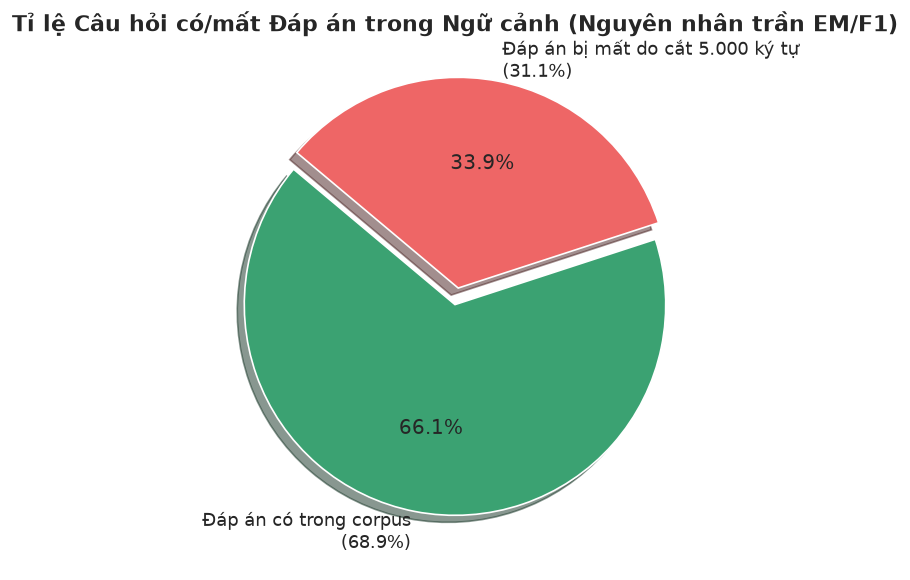

In [11]:
labels = ["Đáp án có trong corpus\n(68.9%)", "Đáp án bị mất do cắt 5.000 ký tự\n(31.1%)"]
sizes = [qa_in_corpus, qa_missing]
colors = ["#3ba272", "#ee6666"]

plt.figure(figsize=(7, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, explode=(0, 0.08), shadow=True)
plt.title("Tỉ lệ Câu hỏi có/mất Đáp án trong Ngữ cảnh (Nguyên nhân trần EM/F1)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 9. Kiểm Tra & Xác Thực Chỉ Mục FAISS
Kiểm tra chỉ mục vector IndexFlatIP được lưu trữ trong `data/faiss.index`.

In [12]:
index_path = DATA_DIR / "faiss.index"
index = faiss.read_index(str(index_path))

print(f"✅ Chỉ mục FAISS: {type(index).__name__}")
print(f" - Tổng số vector đã đánh chỉ mục: {index.ntotal}")
print(f" - Số chiều vector (embedding dim): {index.d}")
print(f" - Khớp 1:1 với số lượng chunks:    {index.ntotal == len(corpus_chunks)}")

✅ Chỉ mục FAISS: IndexFlatIP
 - Tổng số vector đã đánh chỉ mục: 3940
 - Số chiều vector (embedding dim): 384
 - Khớp 1:1 với số lượng chunks:    True


### 10. TỔNG HỢP BẢNG 3-3: KẾT QUẢ KIỂM TRA CHẤT LƯỢNG DỮ LIỆU
Bảng số liệu tổng hợp hoàn chỉnh tương ứng với **Bảng 3-3** trong báo cáo đồ án.

In [13]:
table_3_3_data = [
    {
        "Hạng mục kiểm tra": "Dữ liệu thiếu / rỗng",
        "Kết quả": "Không có câu hỏi, đáp án, gold_doc_id, tiêu đề hay chunk rỗng. Mọi gold_doc_id đều có trong corpus."
    },
    {
        "Hạng mục kiểm tra": "Trùng lặp mức mẫu",
        "Kết quả": "Không có câu hỏi trùng. Có 51 đáp án trùng nhau (ví dụ 'green', 'belgium', mỗi đáp án 3 lần), hợp lý vì các câu hỏi khác nhau."
    },
    {
        "Hạng mục kiểm tra": "Nhiễu văn bản",
        "Kết quả": "3/3.940 chunk còn công thức LaTeX (ID 3648-3650). Có 1 đáp án mang tiền tố bất thường ('A: Basketball') và 2 đáp án kèm chú thích trong ngoặc."
    },
    {
        "Hạng mục kiểm tra": "Chia đoạn",
        "Kết quả": "Overlap đúng 40 từ ở 3.140/3.140 cặp chunk liên tiếp; mọi chunk đều không quá 200 từ."
    },
    {
        "Hạng mục kiểm tra": "Mất cân bằng",
        "Kết quả": "Bài toán không có nhãn lớp nên xét theo loại câu hỏi và kiểu đáp án. Loại câu hỏi: which 28,8%, what 21,6%, who 14,5%, how 3,6%, where/whose/when 1,3%, còn lại 30,3% không có từ để hỏi. Kiểu đáp án: 93,9% là văn bản, 4,6% là số, 1,5% có chữ số. Phân bố loại câu hỏi và độ dài câu hỏi giữa train và test không khác biệt có ý nghĩa (chi-square p = 0,83; Mann-Whitney p = 0,95)."
    },
    {
        "Hạng mục kiểm tra": "Rò rỉ mức câu hỏi và tài liệu",
        "Kết quả": "Không có câu hỏi hay doc_id nào trùng giữa train và test."
    },
    {
        "Hạng mục kiểm tra": "Rò rỉ mức nội dung",
        "Kết quả": "12/120 tài liệu test (11 tiêu đề Wikipedia) trùng bài viết với tài liệu train; 63/612 chunk test (10,3%) giống hệt chunk của tài liệu train; 21/680 ngữ cảnh huấn luyện trùng một chunk của tập test."
    },
    {
        "Hạng mục kiểm tra": "Trùng nội dung giữa các tài liệu",
        "Kết quả": "800 tài liệu chỉ có 746 tiêu đề khác nhau. Có 480/3.940 chunk (12,2%) thuộc 199 đoạn văn bản xuất hiện ở nhiều hơn một tài liệu (liên quan 92 tài liệu)."
    },
    {
        "Hạng mục kiểm tra": "Đáp án có nằm trong ngữ cảnh",
        "Kết quả": "551/800 câu hỏi (68,9%) có đáp án xuất hiện trong chunk của tài liệu gold; 249 câu (31,1%) không có (tập test: 43/120, 35,8%; tập train: 206/680, 30,3%). Có 470/680 mẫu huấn luyện (69,1%) mà ngữ cảnh chứa đáp án."
    },
    {
        "Hạng mục kiểm tra": "Chỉ mục FAISS",
        "Kết quả": "IndexFlatIP, 3.940 vector 384 chiều, khớp với số chunk."
    }
]

df_table_3_3 = pd.DataFrame(table_3_3_data)
pd.set_option('display.max_colwidth', None)
print("=== BẢNG 3-3: KẾT QUẢ KIỂM TRA CHẤT LƯỢNG DỮ LIỆU ===")
display(df_table_3_3)

=== BẢNG 3-3: KẾT QUẢ KIỂM TRA CHẤT LƯỢNG DỮ LIỆU ===


,Hạng mục kiểm tra,Kết quả
0,Dữ liệu thiếu / rỗng,"Không có câu hỏi, đáp án, gold_doc_id, tiêu đề hay chunk rỗng. Mọi gold_doc_id đều có trong corpus."
1,Trùng lặp mức mẫu,"Không có câu hỏi trùng. Có 51 đáp án trùng nhau (ví dụ 'green', 'belgium', mỗi đáp án 3 lần), hợp lý vì các câu hỏi khác nhau."
2,Nhiễu văn bản,3/3.940 chunk còn công thức LaTeX (ID 3648-3650). Có 1 đáp án mang tiền tố bất thường ('A: Basketball') và 2 đáp án kèm chú thích trong ngoặc.
3,Chia đoạn,Overlap đúng 40 từ ở 3.140/3.140 cặp chunk liên tiếp; mọi chunk đều không quá 200 từ.
4,Mất cân bằng,"Bài toán không có nhãn lớp nên xét theo loại câu hỏi và kiểu đáp án. Loại câu hỏi: which 28,8%, what 21,6%, who 14,5%, how 3,6%, where/whose/when 1,3%, còn lại 30,3% không có từ để hỏi. Kiểu đáp án: 93,9% là văn bản, 4,6% là số, 1,5% có chữ số. Phân bố loại câu hỏi và độ dài câu hỏi giữa train và test không khác biệt có ý nghĩa (chi-square p = 0,83; Mann-Whitney p = 0,95)."
5,Rò rỉ mức câu hỏi và tài liệu,Không có câu hỏi hay doc_id nào trùng giữa train và test.
6,Rò rỉ mức nội dung,"12/120 tài liệu test (11 tiêu đề Wikipedia) trùng bài viết với tài liệu train; 63/612 chunk test (10,3%) giống hệt chunk của tài liệu train; 21/680 ngữ cảnh huấn luyện trùng một chunk của tập test."
7,Trùng nội dung giữa các tài liệu,"800 tài liệu chỉ có 746 tiêu đề khác nhau. Có 480/3.940 chunk (12,2%) thuộc 199 đoạn văn bản xuất hiện ở nhiều hơn một tài liệu (liên quan 92 tài liệu)."
8,Đáp án có nằm trong ngữ cảnh,"551/800 câu hỏi (68,9%) có đáp án xuất hiện trong chunk của tài liệu gold; 249 câu (31,1%) không có (tập test: 43/120, 35,8%; tập train: 206/680, 30,3%). Có 470/680 mẫu huấn luyện (69,1%) mà ngữ cảnh chứa đáp án."
9,Chỉ mục FAISS,"IndexFlatIP, 3.940 vector 384 chiều, khớp với số chunk."
